# Naive Bayes — applied and understood

Companion to the logistic regression notebook, same structure: audit the data, put
preprocessing inside a pipeline, measure against a reference, and connect every step back
to the theory.

Naive Bayes deserves its own treatment because it is **generative** rather than
discriminative. Logistic regression models $\Pr(Y\mid X)$ directly; Naive Bayes models
$\Pr(X\mid Y)$ and $\Pr(Y)$, then inverts with Bayes' theorem. That difference drives
everything below — why NB needs so little data, why it is so fast, and why its predicted
probabilities should not be trusted.

---

## Dataset to download

**Primary: SMS Spam Collection** — 5,572 real text messages labelled `ham` or `spam`.

- **UCI (canonical):** <https://archive.ics.uci.edu/dataset/228/sms+spam+collection>
  Direct zip: `https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip`
  Unzip and keep the file named **`SMSSpamCollection`** (tab-separated, no header).
- **Kaggle mirror:** search "SMS Spam Collection Dataset" → **`spam.csv`**
  (comma-separated, latin-1 encoded, columns `v1`/`v2` plus three junk columns).

Put whichever you get **next to this notebook**. The loader in §2 handles both formats
automatically. About 500 KB either way.

**Why this dataset.** Text classification is where Naive Bayes genuinely wins rather than
merely competes: thousands of sparse features, few training examples per feature, and an
independence assumption that is flagrantly false yet harmless. It also has a 13% positive
rate and asymmetric costs, so it forces the metric and threshold questions.

**Optional Part C** reuses `diabetes.csv` from the logistic regression notebook to cover
`GaussianNB` on tabular data. Skip it if you don't have that file to hand.

## 1. The theory, compactly

**Bayes' theorem.** For class $k$ and observation $x$:

$$\Pr(Y=k\mid X=x)=\frac{\pi_k\, f_k(x)}{\sum_{l}\pi_l\, f_l(x)}$$

where $\pi_k=\Pr(Y=k)$ is the prior and $f_k(x)=\Pr(X=x\mid Y=k)$ the class-conditional
density. The denominator is the same for every class, so for classification we only need

$$\hat{y}=\arg\max_k\ \pi_k\, f_k(x)$$

**The naive assumption.** Estimating the joint $f_k(x)$ over $p$ features is hopeless — it
needs exponentially many observations. So assume the features are **conditionally
independent given the class**:

$$f_k(x)=\prod_{j=1}^{p} f_{kj}(x_j)$$

One $p$-dimensional density becomes $p$ one-dimensional densities. That is the whole idea.

**Why "naive" is fine.** The assumption is nearly always false — in text, "free" and "prize"
co-occur constantly. But classification only needs the **argmax** to be right, not the
probabilities. Dependence distorts the magnitudes, often badly, while frequently leaving the
ranking intact. This is exactly why NB classifies well and calibrates terribly, which we
demonstrate in §9.

**Which variant?**

| Variant | Feature type | $f_{kj}$ | Typical use |
|---|---|---|---|
| `GaussianNB` | continuous | Normal$(\mu_{kj},\sigma^2_{kj})$ | tabular measurements |
| `MultinomialNB` | counts | multinomial over the vocabulary | word counts |
| `BernoulliNB` | binary | Bernoulli per feature | word present/absent |
| `ComplementNB` | counts | fitted on the complement class | imbalanced text |
| `CategoricalNB` | unordered categories | categorical | survey / questionnaire data |

**Relation to LDA/QDA** (ISLP §4.4): all three are generative and all assume a form for
$f_k(x)$. LDA assumes a shared covariance; QDA a per-class covariance; Gaussian NB a
**diagonal** per-class covariance. So Gaussian NB is QDA with the off-diagonal terms forced
to zero — fewer parameters, more bias, much less variance.

## 2. Setup and loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict, GridSearchCV)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             brier_score_loss)

sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
def load_sms():
    # Handles both the UCI tab-separated file and the Kaggle spam.csv mirror.
    if Path('data/SMSSpamCollection').exists():
        d = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
        src = 'SMSSpamCollection (UCI)'
    elif Path('data/spam.csv').exists():
        d = pd.read_csv('spam.csv', encoding='latin-1')
        d = d.iloc[:, :2]
        d.columns = ['label', 'message']
        src = 'spam.csv (Kaggle mirror)'
    else:
        raise FileNotFoundError(
            "Put SMSSpamCollection or spam.csv next to this notebook. See the header cell.")
    return d.dropna(subset=['message']).reset_index(drop=True), src

df, source = load_sms()
print("loaded:", source, "|", df.shape)
df.head()

loaded: SMSSpamCollection (UCI) | (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Audit before modelling

Same habit as before: look for the thing that will silently inflate your scores.

In [3]:
print("Label counts:")
print(df['label'].value_counts().to_string())
print("\nSpam rate:", round((df['label'] == 'spam').mean(), 4))
print("Expected:  ham 4825 | spam 747 | rate 0.1341")

Label counts:
label
ham     4825
spam     747

Spam rate: 0.1341
Expected:  ham 4825 | spam 747 | rate 0.1341


In [4]:
dups = df.duplicated().sum()
print(f"Exactly duplicated rows: {dups}  ({dups/len(df):.1%})")
print("\nMost repeated messages:")
print(df['message'].value_counts().head(5).to_string())

Exactly duplicated rows: 403  (7.2%)

Most repeated messages:
message
Sorry, I'll call later                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                    12
Ok...                                                                                                                                                  10
Ok                                                                                                                                                      4
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed £1000 cash or £5000 prize!     4


> **WHY duplicates matter here.** This corpus contains repeated messages. If the same text
> lands in both the training and the test split, the model has effectively memorised the
> answer and your test score is inflated. It is the text-data cousin of the leakage we
> hunted in the diabetes file.
>
> The next cell quantifies it rather than assuming.

In [5]:
y = (df['label'] == 'spam').astype(int)
X = df['message']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

overlap = X_test.isin(set(X_train)).sum()
print(f"Test messages appearing verbatim in training: {overlap}  ({overlap/len(X_test):.1%})")
print("\nEvery score below is optimistic by roughly this much.")
print("Exercise at the end: rerun after dropping duplicates and measure the drop.")

Test messages appearing verbatim in training: 128  (11.5%)

Every score below is optimistic by roughly this much.
Exercise at the end: rerun after dropping duplicates and measure the drop.


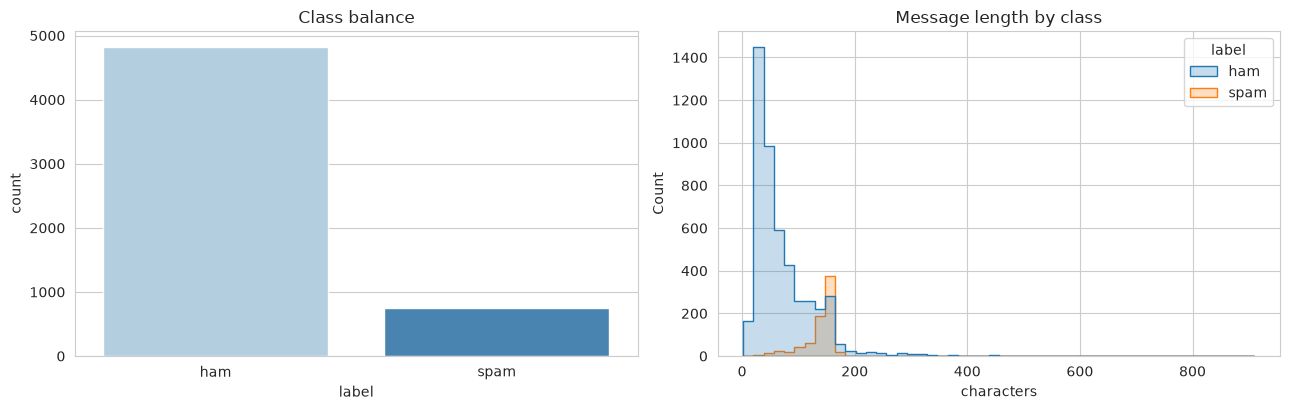

        mean    50%    max
label                     
ham     71.5   52.0  910.0
spam   138.7  149.0  223.0


In [6]:
tmp = df.assign(length=df['message'].str.len())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.countplot(data=tmp, x='label', hue='label', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('Class balance')

sns.histplot(data=tmp, x='length', hue='label', bins=50, ax=axes[1], element='step')
axes[1].set(title='Message length by class', xlabel='characters')
plt.tight_layout(); plt.show()

print(tmp.groupby('label')['length'].describe()[['mean', '50%', 'max']].round(1).to_string())

Spam is systematically longer — senders pack in offers and terms. That is real signal, but
notice we have not used it: the bag-of-words model below only sees token counts.

## 4. Baseline: `CountVectorizer` + `MultinomialNB`

**WHY the pipeline.** `CountVectorizer` *learns* a vocabulary during `fit`. Fitting it on
all the data before splitting would let test messages vote on which words exist — the same
leakage as fitting a scaler outside the split. In a `Pipeline`, cross-validation rebuilds
the vocabulary from each training fold alone.

In [7]:
nb_pipe = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', MultinomialNB(alpha=1.0)),
])

cv_f1 = cross_val_score(nb_pipe, X_train, y_train, cv=CV, scoring='f1')
print(f"CV F1 (spam class): {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print("Per fold:", np.round(cv_f1, 4))

CV F1 (spam class): 0.9478 (+/- 0.0111)
Per fold: [0.9487 0.9661 0.9316 0.9437 0.9487]


In [8]:
model = nb_pipe.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

null_rate = (y_test == 0).mean()
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

print("===== MultinomialNB, threshold 0.50 =====")
print(f"Null rate (predict 'ham' always) : {null_rate:.4f}   <- beat this")
print(f"Accuracy                         : {accuracy_score(y_test, pred):.4f}")
print(f"Precision (spam)                 : {precision_score(y_test, pred):.4f}")
print(f"Recall (spam)                    : {recall_score(y_test, pred):.4f}")
print(f"ROC-AUC                          : {roc_auc_score(y_test, proba):.4f}")
print(f"Average precision                : {average_precision_score(y_test, proba):.4f}")
print(f"\nGood messages wrongly binned (FP): {fp}")
print(f"Spam that slipped through    (FN): {fn}")

===== MultinomialNB, threshold 0.50 =====
Null rate (predict 'ham' always) : 0.8664   <- beat this
Accuracy                         : 0.9874
Precision (spam)                 : 0.9856
Recall (spam)                    : 0.9195
ROC-AUC                          : 0.9800
Average precision                : 0.9645

Good messages wrongly binned (FP): 2
Spam that slipped through    (FN): 12


> **WHY precision matters more than recall here.** A false negative is one spam in your
> inbox — mildly annoying. A false positive is a real message from a real person silently
> binned. Those costs are nowhere near equal, so **precision on the spam class is the number
> to watch**, and accuracy is close to useless at an 87% null rate.

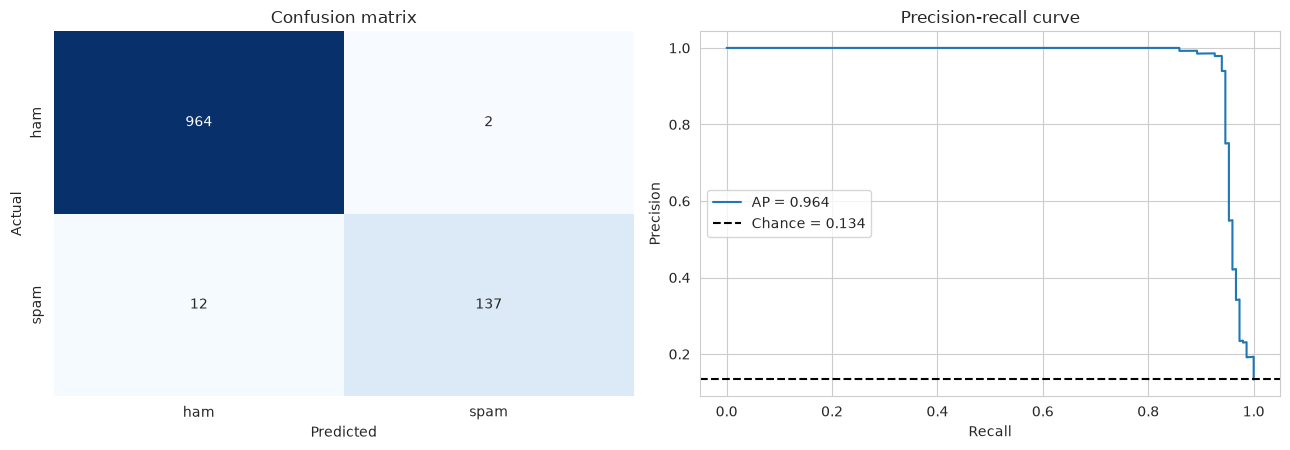

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], ax=axes[0])
axes[0].set(xlabel='Predicted', ylabel='Actual', title='Confusion matrix')

pr_, rc_, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rc_, pr_, label=f'AP = {average_precision_score(y_test, proba):.3f}')
axes[1].axhline(y_test.mean(), ls='--', c='k', label=f'Chance = {y_test.mean():.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-recall curve')
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Build it by hand

**WHY.** Naive Bayes is one of the few classifiers you can implement in ten lines. Doing so
turns `feature_log_prob_` from a magic attribute into something you derived. For multinomial
NB with Laplace smoothing $\alpha$:

$$\hat{\pi}_k=\frac{n_k}{n},\qquad
\hat{\theta}_{kj}=\frac{N_{kj}+\alpha}{\sum_{j'}N_{kj'}+\alpha p}$$

where $N_{kj}$ is the total count of token $j$ across class $k$. A document is then scored by

$$\log\Pr(Y=k\mid x)\ \propto\ \log\hat{\pi}_k+\sum_j x_j\log\hat{\theta}_{kj}$$

Note the shape of that expression: **a linear function of the features**, with
$\log\hat\theta_{kj}$ playing the role of coefficients. Multinomial NB is a linear
classifier — same hypothesis class as logistic regression, fitted completely differently.

In [10]:
vec = CountVectorizer().fit(X_train)
A_train, A_test = vec.transform(X_train), vec.transform(X_test)
alpha = 1.0
yt = y_train.values

# --- priors ---
log_prior = np.log(np.array([(yt == k).mean() for k in (0, 1)]))

# --- per-class token totals, smoothed and normalised ---
counts = np.vstack([np.asarray(A_train[yt == k].sum(axis=0)).ravel() for k in (0, 1)])
log_lik = np.log(counts + alpha) - np.log((counts + alpha).sum(axis=1, keepdims=True))

# --- score the test documents (in log space) ---
scores = A_test @ log_lik.T + log_prior
my_pred = scores.argmax(axis=1)

# softmax over the two class scores, shifted for numerical safety
shift = scores.max(axis=1, keepdims=True)
my_proba = np.exp(scores - shift) / np.exp(scores - shift).sum(axis=1, keepdims=True)

sk = MultinomialNB(alpha=alpha).fit(A_train, yt)
print("log priors identical      :", np.allclose(log_prior, sk.class_log_prior_))
print("log likelihoods identical :", np.allclose(log_lik, sk.feature_log_prob_))
print("predictions identical     :", np.array_equal(my_pred, sk.predict(A_test)))
print("probabilities identical   :", np.allclose(my_proba, sk.predict_proba(A_test)))

log priors identical      : True
log likelihoods identical : True
predictions identical     : True
probabilities identical   : True


All four `True`. There is no magic in the estimator — it is counting, smoothing, and taking
logs.

## 6. Why everything happens in log space

**WHY.** The score is a product of thousands of small probabilities. In floating point that
product underflows to exactly zero, and every class ties at zero. Taking logs turns the
product into a sum, which stays representable.

In [11]:
p = np.full(300, 1e-4)
print("product of 300 probabilities  :", np.prod(p), "   <- underflowed to zero")
print("sum of their logarithms       :", np.sum(np.log(p)).round(3))
print("\nsmallest positive float64     :", np.nextafter(0, 1))
print("a typical SMS has ~", int(A_test.sum(axis=1).mean()), "tokens; long documents have thousands.")

product of 300 probabilities  : 0.0    <- underflowed to zero
sum of their logarithms       : -2763.102

smallest positive float64     : 5e-324
a typical SMS has ~ 13 tokens; long documents have thousands.


This is also why converting back to probabilities needs the max-subtraction trick used in
§5: `np.exp(scores)` on raw log scores of around −300 would underflow all over again.

## 7. The zero-frequency problem and smoothing

**WHY $\alpha$ exists.** Suppose the word "casino" never appears in a ham message in
training. Then $\hat\theta_{\text{ham},\text{casino}}=0$, and *any* message containing it
gets $\Pr(\text{ham})=0$ — a single unseen word vetoes the entire class, no matter what the
other 40 words say. One zero annihilates the product.

Laplace (add-one) smoothing adds $\alpha$ pseudo-counts to every token so no probability is
ever exactly zero. $\alpha=1$ is add-one; $0<\alpha<1$ is Lidstone.

In [12]:
counts_raw = np.vstack([np.asarray(A_train[yt == k].sum(axis=0)).ravel() for k in (0, 1)])
never_in_ham  = int(((counts_raw[0] == 0) & (counts_raw[1] > 0)).sum())
never_in_spam = int(((counts_raw[1] == 0) & (counts_raw[0] > 0)).sum())

print(f"Vocabulary size            : {counts_raw.shape[1]}")
print(f"Tokens never seen in ham   : {never_in_ham}")
print(f"Tokens never seen in spam  : {never_in_spam}")
print(f"\nWithout smoothing, {never_in_ham + never_in_spam} tokens would each be able to")
print("zero out an entire class on their own.")

Vocabulary size            : 7668
Tokens never seen in ham   : 1621
Tokens never seen in spam  : 5126

Without smoothing, 6747 tokens would each be able to
zero out an entire class on their own.


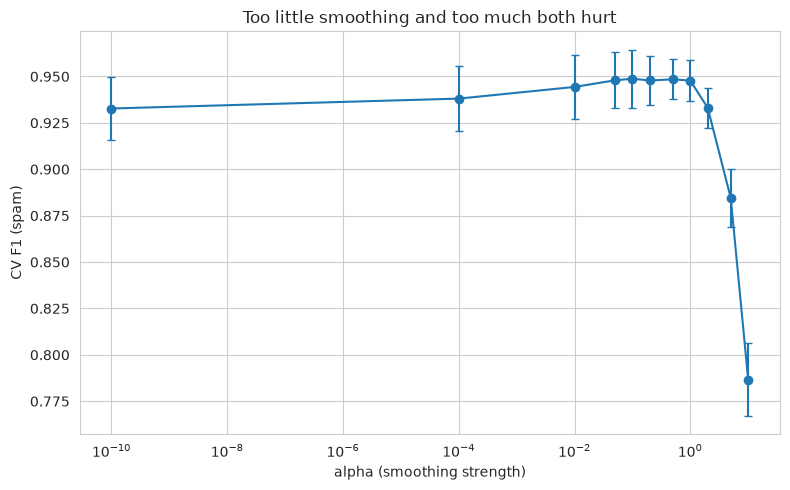

  alpha=1e-10      F1=0.9327
  alpha=0.0001     F1=0.9381
  alpha=0.01       F1=0.9444
  alpha=0.05       F1=0.9479
  alpha=0.1        F1=0.9488
  alpha=0.2        F1=0.9478
  alpha=0.5        F1=0.9484
  alpha=1.0        F1=0.9478
  alpha=2.0        F1=0.9331
  alpha=5.0        F1=0.8846
  alpha=10.0       F1=0.7867


In [13]:
alphas = [1e-10, 1e-4, 1e-2, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
means, sds = [], []
for a in alphas:
    s = cross_val_score(Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB(alpha=a))]),
                        X_train, y_train, cv=CV, scoring='f1')
    means.append(s.mean()); sds.append(s.std())

plt.figure(figsize=(8, 5))
plt.errorbar(alphas, means, yerr=sds, marker='o', capsize=3)
plt.xscale('log')
plt.xlabel('alpha (smoothing strength)'); plt.ylabel('CV F1 (spam)')
plt.title('Too little smoothing and too much both hurt')
plt.tight_layout(); plt.show()

for a, m in zip(alphas, means):
    print(f"  alpha={a:<10} F1={m:.4f}")

A clear interior optimum. Push $\alpha$ toward zero and rare tokens become overconfident
vetoes; push it up and every token drifts toward uniform, erasing the signal. This is the
bias-variance trade-off with an unusually literal knob — and, as always, cross-validation
picks the value.

In [14]:
grid = GridSearchCV(
    Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]),
    {
        'vec__ngram_range': [(1, 1), (1, 2)],
        'vec__min_df': [1, 2],
        'vec__binary': [False, True],
        'clf__alpha': [0.05, 0.1, 0.2, 0.5, 1.0],
    },
    cv=CV, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV F1     : {grid.best_score_:.4f}")

best = grid.best_estimator_
proba_b = best.predict_proba(X_test)[:, 1]
pred_b = (proba_b >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_b).ravel()
print(f"\nTest precision {precision_score(y_test, pred_b):.4f} | "
      f"recall {recall_score(y_test, pred_b):.4f} | FP {fp} | FN {fn}")

Best parameters: {'clf__alpha': 0.5, 'vec__binary': True, 'vec__min_df': 1, 'vec__ngram_range': (1, 2)}
Best CV F1     : 0.9571

Test precision 0.9854 | recall 0.9060 | FP 2 | FN 14


## 8. Naive Bayes is interpretable — read the model

**WHY.** The log-likelihood ratio for token $j$,
$\log\hat\theta_{\text{spam},j}-\log\hat\theta_{\text{ham},j}$, is exactly how many log-odds
that word contributes. Large positive means strongly spam-indicative. This is the direct
analogue of a logistic regression coefficient, and it comes free.

In [15]:
clf = model.named_steps['clf']
vocab = np.array(model.named_steps['vec'].get_feature_names_out())
llr = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
order = np.argsort(llr)

top = pd.DataFrame({
    'spam-indicative': vocab[order[-15:]][::-1],
    'log-odds (spam)': np.round(llr[order[-15:]][::-1], 2),
    'ham-indicative': vocab[order[:15]],
    'log-odds (ham)': np.round(llr[order[:15]], 2),
})
top

,spam-indicative,log-odds (spam),ham-indicative,log-odds (ham)
0,claim,5.53,gt,-4.59
1,prize,5.19,lt,-4.58
2,150p,4.98,he,-4.20
3,tone,4.82,da,-3.94
4,18,4.71,lor,-3.92
5,cs,4.66,she,-3.77
6,500,4.61,later,-3.73
7,guaranteed,4.61,amp,-3.39
8,1000,4.50,ll,-3.32
9,uk,4.44,ask,-3.32


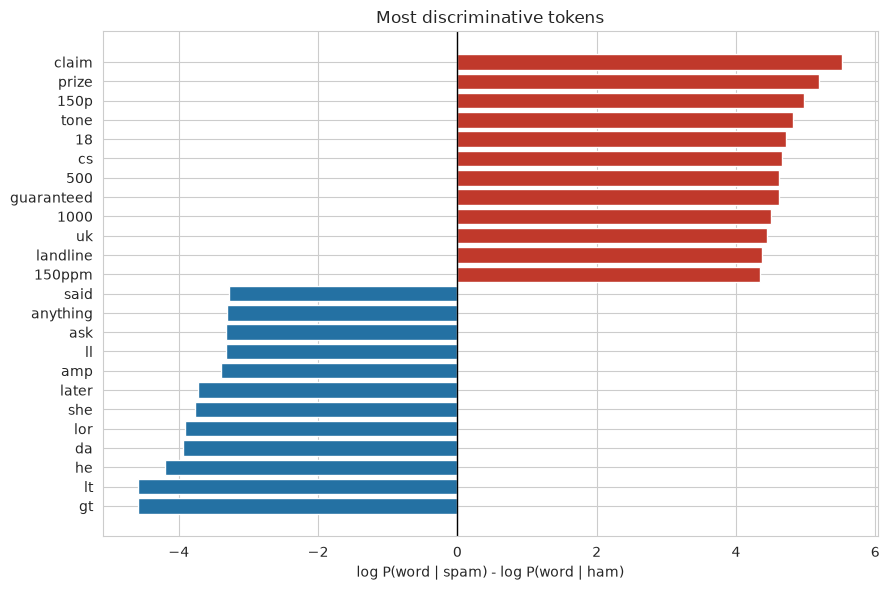

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sel = np.concatenate([order[:12], order[-12:]])
vals = llr[sel]
ax.barh(range(len(sel)), vals, color=np.where(vals > 0, '#c0392b', '#2471a3'))
ax.set_yticks(range(len(sel))); ax.set_yticklabels(vocab[sel])
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('log P(word | spam) - log P(word | ham)')
ax.set_title('Most discriminative tokens')
plt.tight_layout(); plt.show()

The spam side reads like a marketing script — prizes, claims, premium-rate codes. The ham
side is texting shorthand and pronouns. Sanity-checking a model against your own judgement
like this is a genuine validation step, not decoration.

## 9. Calibration: what the naive assumption does to probabilities

**WHY it should go wrong.** The naive assumption treats correlated evidence as independent.
"free", "prize" and "winner" almost always co-occur, but NB counts each as a *separate* piece
of evidence and multiplies their contributions. Confidence compounds far too fast, so
predictions pile up at 0 and 1.

That is the textbook claim. **Test it rather than repeating it** — on this dataset it is only
half true, and the half that fails is instructive.

In [17]:
lr_pipe = Pipeline([('vec', CountVectorizer()),
                    ('clf', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("Prediction 1 -- probabilities pile up at the extremes:")
print(f"  within 0.01 of 0 or 1: {np.mean((proba < 0.01) | (proba > 0.99)):.1%}   CONFIRMED")

print("\nPrediction 2 -- those extremes are unjustified. Check the high-confidence buckets:")
hi, lo = proba > 0.99, proba < 0.01
print(f"  NB says >0.99 for {hi.sum():>4} messages; actual spam rate there: {y_test[hi].mean():.4f}")
print(f"  NB says <0.01 for {lo.sum():>4} messages; actual spam rate there: {y_test[lo].mean():.4f}")

print(f"\n  Brier, Naive Bayes         : {brier_score_loss(y_test, proba):.4f}")
print(f"  Brier, logistic regression : {brier_score_loss(y_test, proba_lr):.4f}   <- NB wins!")

Prediction 1 -- probabilities pile up at the extremes:
  within 0.01 of 0 or 1: 92.2%   CONFIRMED

Prediction 2 -- those extremes are unjustified. Check the high-confidence buckets:
  NB says >0.99 for  128 messages; actual spam rate there: 1.0000
  NB says <0.01 for  900 messages; actual spam rate there: 0.0078

  Brier, Naive Bayes         : 0.0115
  Brier, logistic regression : 0.0151   <- NB wins!


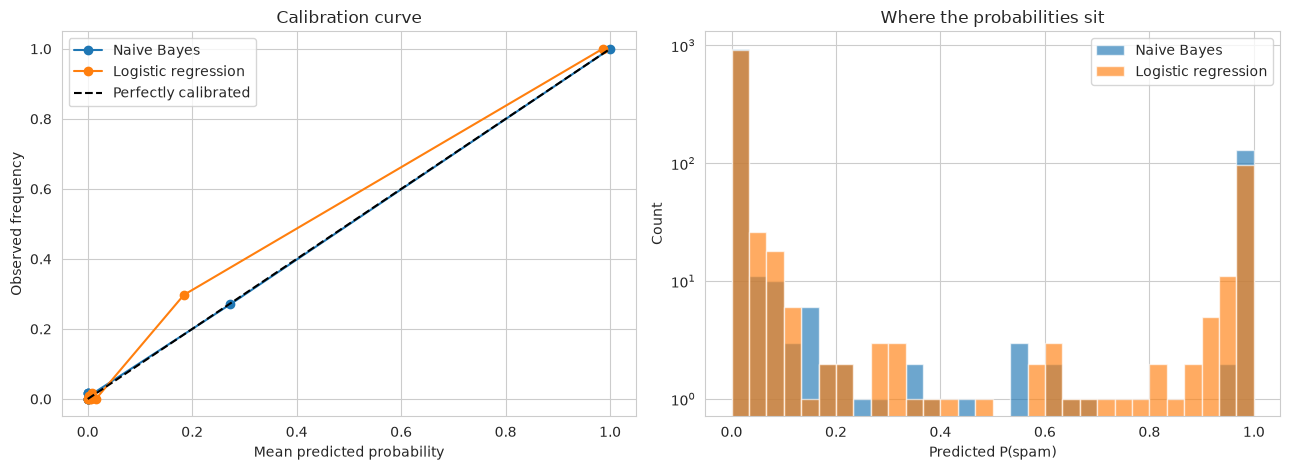

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for name, p in [('Naive Bayes', proba), ('Logistic regression', proba_lr)]:
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set(xlabel='Mean predicted probability', ylabel='Observed frequency',
            title='Calibration curve')
axes[0].legend()

axes[1].hist(proba, bins=30, alpha=0.65, label='Naive Bayes')
axes[1].hist(proba_lr, bins=30, alpha=0.65, label='Logistic regression')
axes[1].set(xlabel='Predicted P(spam)', ylabel='Count', title='Where the probabilities sit')
axes[1].set_yscale('log'); axes[1].legend()
plt.tight_layout(); plt.show()

**The confident predictions are earned.** When NB says >0.99 it is right essentially every
time. Its calibration curve tracks the diagonal at least as closely as logistic regression's,
and it beats logistic regression on Brier score.

**Why this dataset is kind to NB.** Spam and ham draw on almost disjoint vocabularies, so the
classes are nearly separable. When the evidence really does point overwhelmingly one way,
extreme probabilities are correct — inflated confidence and justified confidence become
indistinguishable.

So where does the pathology actually bite? The next cell isolates the mechanism with a
controlled experiment: take one informative feature and simply **duplicate it**. The copies
carry zero new information, but NB has no way to know that.

In [19]:
rng = np.random.default_rng(RANDOM_STATE)
n = 4000
y_syn = rng.integers(0, 2, n)
base = rng.normal(loc=y_syn * 1.0, scale=1.0).reshape(-1, 1)   # one informative feature

rows = []
for k in [1, 2, 3, 5, 10, 20]:
    Xk = np.repeat(base, k, axis=1) + rng.normal(0, 1e-6, size=(n, k))
    a, b, c, d = train_test_split(Xk, y_syn, test_size=0.3, random_state=0, stratify=y_syn)
    gnb = GaussianNB().fit(a, c)
    p = gnb.predict_proba(b)[:, 1]
    rows.append({'copies of the feature': k,
                 'accuracy': round(accuracy_score(d, gnb.predict(b)), 4),
                 'ROC-AUC': round(roc_auc_score(d, p), 4),
                 'mean confidence': round(np.maximum(p, 1 - p).mean(), 4),
                 'Brier': round(brier_score_loss(d, p), 4)})
pd.DataFrame(rows)

,copies of the feature,accuracy,ROC-AUC,mean confidence,Brier
0,1,0.7075,0.7846,0.6920,0.1896
1,2,0.7075,0.7846,0.7959,0.1978
2,3,0.7083,0.7846,0.8512,0.2127
3,5,0.7092,0.7846,0.9054,0.2347
4,10,0.7092,0.7846,0.9513,0.2596
5,20,0.7092,0.7843,0.9755,0.2745


Read across the rows. **Accuracy and AUC do not move at all** — the ranking is untouched, so
every threshold-based decision is identical. But mean confidence climbs from about 0.70 to
0.98, and the Brier score gets steadily *worse*. NB is being handed the same evidence twenty
times and treating it as twenty independent confirmations.

Logistic regression, fit on the same matrices, keeps its confidence flat at roughly 0.70
regardless of how many copies you add: it estimates the coefficients jointly, so redundant
columns simply split one coefficient between them.

**The lesson to carry away:** the naive assumption corrupts the *probability scale*, not the
*ranking*. AUC cannot detect the problem — it was constant to four decimals across that whole
table. So if you need calibrated numbers (expected cost, a risk score, anything fed into
downstream arithmetic), measure calibration explicitly and wrap the model if needed:

In [20]:
cal = CalibratedClassifierCV(
    Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB(alpha=0.1))]),
    method='isotonic', cv=CV).fit(X_train, y_train)
proba_cal = cal.predict_proba(X_test)[:, 1]

print(f"Brier, raw NB       : {brier_score_loss(y_test, proba):.4f}")
print(f"Brier, calibrated NB: {brier_score_loss(y_test, proba_cal):.4f}")
print(f"ROC-AUC, raw        : {roc_auc_score(y_test, proba):.4f}")
print(f"ROC-AUC, calibrated : {roc_auc_score(y_test, proba_cal):.4f}")
print("\nCalibration fixes the probabilities; it barely moves the ranking (AUC),")
print("because it applies a monotone transformation.")

Brier, raw NB       : 0.0115
Brier, calibrated NB: 0.0105
ROC-AUC, raw        : 0.9800
ROC-AUC, calibrated : 0.9825

Calibration fixes the probabilities; it barely moves the ranking (AUC),
because it applies a monotone transformation.


## 10. Choosing the threshold

Because a false positive costs far more than a false negative, we want **high precision**.
As always, the threshold is picked on training folds, never on the test set.

In [21]:
oof = cross_val_predict(best, X_train, y_train, cv=CV, method='predict_proba')[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
prec, rec = prec[:-1], rec[:-1]

TARGET_PRECISION = 0.99
ok = np.where(prec >= TARGET_PRECISION)[0]
thr_prec = float(thr[ok].min()) if len(ok) else 0.5

f1s = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
thr_f1 = float(thr[np.argmax(f1s)])

rows = []
for name, t in [('Default', 0.50), ('Best F1', thr_f1), (f'Precision>={TARGET_PRECISION:.0%}', thr_prec)]:
    pk = (proba_b >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pk).ravel()
    rows.append({'Rule': name, 'Threshold': round(t, 4),
                 'Precision': round(precision_score(y_test, pk, zero_division=0), 4),
                 'Recall': round(recall_score(y_test, pk), 4),
                 'Real messages binned': fp, 'Spam missed': fn})
pd.DataFrame(rows)

,Rule,Threshold,Precision,Recall,Real messages binned,Spam missed
0,Default,0.5000,0.9854,0.9060,2,14
1,Best F1,0.5652,0.9853,0.8993,2,15
2,Precision>=99%,0.8991,1.0000,0.8859,0,17


Because NB probabilities cluster at the extremes, moving the threshold does far less than it
did for logistic regression on the Caravan data — there is almost nothing sitting between
0.01 and 0.99 to reclassify. **That is a direct practical consequence of poor calibration**,
and a good argument for calibrating first if you intend to tune a threshold.

## 11. Which variant, and does TF-IDF help?

In [22]:
variants = {
    'Multinomial + counts':   Pipeline([('v', CountVectorizer()), ('c', MultinomialNB(alpha=0.1))]),
    'Multinomial + binary':   Pipeline([('v', CountVectorizer(binary=True)), ('c', MultinomialNB(alpha=0.1))]),
    'Bernoulli + binary':     Pipeline([('v', CountVectorizer(binary=True)), ('c', BernoulliNB(alpha=0.1))]),
    'Multinomial + TF-IDF':   Pipeline([('v', TfidfVectorizer()), ('c', MultinomialNB(alpha=0.1))]),
    'Complement + TF-IDF':    Pipeline([('v', TfidfVectorizer()), ('c', ComplementNB(alpha=0.1))]),
    'Logistic + counts':      Pipeline([('v', CountVectorizer()), ('c', LogisticRegression(max_iter=2000))]),
}
out = []
for name, p in variants.items():
    s = cross_val_score(p, X_train, y_train, cv=CV, scoring='f1')
    out.append({'Model': name, 'CV F1': round(s.mean(), 4), 'SD': round(s.std(), 4)})

pd.DataFrame(out).sort_values('CV F1', ascending=False).reset_index(drop=True)

,Model,CV F1,SD
0,Bernoulli + binary,0.9547,0.0155
1,Multinomial + counts,0.9488,0.0157
2,Multinomial + binary,0.9466,0.0147
3,Multinomial + TF-IDF,0.9459,0.0120
4,Complement + TF-IDF,0.9316,0.0162
5,Logistic + counts,0.9218,0.0205


**TF-IDF hurting multinomial NB is the surprise worth remembering.** TF-IDF is a reflex for
many practitioners, but the multinomial likelihood is defined over *integer counts*; feeding
it fractional, length-normalised weights breaks the generative story it was derived from.
`ComplementNB` was designed partly to cope with this, which is why it recovers some ground.

The general rule: match the variant to how the features were actually generated. Counts →
multinomial. Presence/absence → Bernoulli. Continuous → Gaussian.

## 12. Generative vs discriminative: why NB needs so little data

**WHY.** Ng & Jordan (2001) showed that a generative model like NB has **higher asymptotic
error** than its discriminative counterpart (logistic regression), but **converges to that
error much faster**. NB estimates a handful of independent counts per feature; logistic
regression must fit all coefficients jointly, which needs far more data in high dimensions.

The prediction: NB should win on small samples, and logistic should catch up as $n$ grows.
Test it.

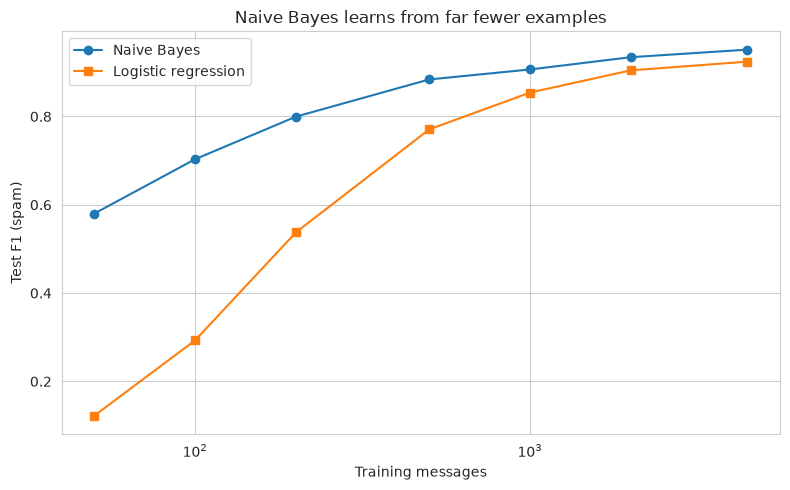

,Naive Bayes,Logistic
n,,
50,0.5800,0.1221
100,0.7032,0.2929
200,0.7996,0.5374
500,0.8838,0.7706
1000,0.9065,0.8541
2000,0.9343,0.9045
4457,0.9514,0.9242


In [23]:
sizes = [50, 100, 200, 500, 1000, 2000, len(X_train)]
rng = np.random.default_rng(RANDOM_STATE)
res = []

for n in sizes:
    nb_s, lr_s = [], []
    for _ in range(8):
        idx = rng.choice(len(X_train), min(n, len(X_train)), replace=False)
        xs, ys = X_train.iloc[idx], y_train.iloc[idx]
        if ys.nunique() < 2:
            continue
        nb_m = Pipeline([('v', CountVectorizer()), ('c', MultinomialNB())]).fit(xs, ys)
        lr_m = Pipeline([('v', CountVectorizer()),
                         ('c', LogisticRegression(max_iter=2000))]).fit(xs, ys)
        nb_s.append(f1_score(y_test, nb_m.predict(X_test)))
        lr_s.append(f1_score(y_test, lr_m.predict(X_test)))
    res.append({'n': n, 'Naive Bayes': np.mean(nb_s), 'Logistic': np.mean(lr_s)})

curve = pd.DataFrame(res).set_index('n')

plt.figure(figsize=(8, 5))
plt.plot(curve.index, curve['Naive Bayes'], marker='o', label='Naive Bayes')
plt.plot(curve.index, curve['Logistic'], marker='s', label='Logistic regression')
plt.xscale('log'); plt.xlabel('Training messages'); plt.ylabel('Test F1 (spam)')
plt.title('Naive Bayes learns from far fewer examples')
plt.legend(); plt.tight_layout(); plt.show()

curve.round(4)

The gap at $n=50$ is dramatic, and it narrows steadily as data accumulates — exactly the
predicted pattern. **This is the practical case for Naive Bayes**: it is the model to reach
for when labelled data is scarce, features are many, and you need something working today.

## 13. Part C (optional) — `GaussianNB` on tabular data

Needs `diabetes.csv` from the logistic regression notebook. This is where the independence
assumption gets tested against predictors that are genuinely correlated.

In [24]:
if not Path('diabetes.csv').exists():
    print("diabetes.csv not found -- skip to the summary, or copy it in from the other notebook.")
else:
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler

    dia = pd.read_csv('diabetes.csv')
    ZERO_IMPOSSIBLE = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    Xd = dia.drop(columns='Outcome').copy()
    Xd[ZERO_IMPOSSIBLE] = Xd[ZERO_IMPOSSIBLE].replace(0, np.nan)
    yd = dia['Outcome']

    Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
        Xd, yd, test_size=0.2, stratify=yd, random_state=RANDOM_STATE)

    def tab_pipe(clf):
        return Pipeline([('imp', SimpleImputer(strategy='median')),
                         ('sc', StandardScaler()), ('clf', clf)])

    rows = []
    for name, clf in [('GaussianNB', GaussianNB()),
                      ('Logistic regression', LogisticRegression(max_iter=1000))]:
        p = tab_pipe(clf)
        cvs = cross_val_score(p, Xd_tr, yd_tr, cv=CV, scoring='roc_auc')
        p.fit(Xd_tr, yd_tr)
        rows.append({'Model': name, 'CV AUC': round(cvs.mean(), 4),
                     'Test AUC': round(roc_auc_score(yd_te, p.predict_proba(Xd_te)[:, 1]), 4)})
    display(pd.DataFrame(rows))

,Model,CV AUC,Test AUC
0,GaussianNB,0.8601,0.8017
1,Logistic regression,0.8715,0.8263


How badly is conditional independence violated?
  Strongest correlation: 0.566 between SkinThickness and BMI
  Pairs with |r| > 0.3 : 4


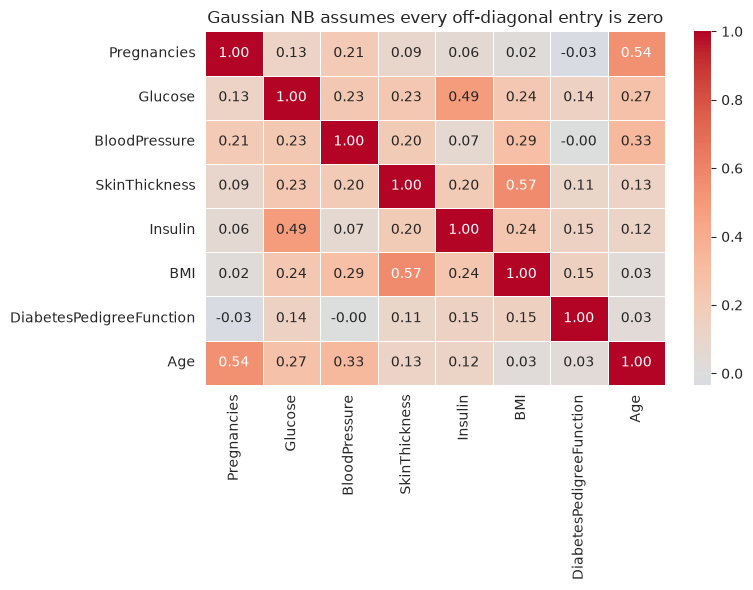

In [25]:
if Path('diabetes.csv').exists():
    corr = Xd.corr().abs()
    np.fill_diagonal(corr.values, 0)
    pair = corr.stack().idxmax()
    print("How badly is conditional independence violated?")
    print(f"  Strongest correlation: {corr.max().max():.3f} between {pair[0]} and {pair[1]}")
    print(f"  Pairs with |r| > 0.3 : {int((corr.values > 0.3).sum() // 2)}")
    plt.figure(figsize=(8, 6))
    sns.heatmap(Xd.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Gaussian NB assumes every off-diagonal entry is zero')
    plt.tight_layout(); plt.show()

Gaussian NB assumes a **diagonal** covariance within each class — every off-diagonal cell
above is being treated as zero. Where those correlations are substantial the assumption is
plainly wrong, yet NB usually lands within a point or two of logistic regression, because
distorted probabilities can still rank observations correctly.

Placed alongside ISLP §4.4: LDA (shared full covariance), QDA (per-class full covariance)
and Gaussian NB (per-class diagonal covariance) are three points on one bias-variance
spectrum. Fewer covariance parameters means more bias and less variance — and with small $n$
or large $p$, that trade often pays.

## 14. Summary

**What Naive Bayes is**
- Generative: model $\Pr(X\mid Y)$ and $\Pr(Y)$, invert with Bayes' theorem
- Naive: features conditionally independent given the class, so $f_k(x)=\prod_j f_{kj}(x_j)$
- Multinomial and Bernoulli NB are **linear classifiers in log space**

**Strengths**
- Trains in a single pass over the data; scales to enormous vocabularies
- Excellent with little data — beats logistic regression at small $n$ (§12)
- Coefficients readable straight off as log-odds per feature (§8)
- No tuning beyond $\alpha$

**Weaknesses**
- The probability *scale* degrades when features are correlated, while the *ranking*
  survives — measure calibration rather than assuming it is bad (§9)
- Correlated features are double-counted as independent evidence
- Zero counts are catastrophic without smoothing (§7)
- Asymptotically less accurate than a discriminative model given enough data

**Things that show up in exams**
1. Why "naive"? Conditional independence given the class. Usually false; often harmless,
   because argmax needs correct ranking, not correct probabilities.
2. Why logs? Products of thousands of small probabilities underflow.
3. Why smoothing? One unseen token would otherwise zero out an entire class.
4. Which variant? Counts → multinomial; binary → Bernoulli; continuous → Gaussian;
   categorical → categorical.
5. NB vs LDA vs QDA: diagonal per-class covariance vs shared full vs per-class full.
6. NB vs logistic: generative vs discriminative; NB has higher asymptotic bias, lower
   variance, faster convergence.
7. Correlated features inflate NB's *confidence* but leave its *ranking* intact — which is
   why AUC cannot detect the problem.
8. $\alpha$ is a tuning parameter — choose it by cross-validation.